In [1]:
import os
os.chdir("../")
configs_file = "train_fno_pi"

In [2]:
import os
from functools import partial

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from solidification.configs import load_configs
configs = load_configs(configs_file).Configs()

# from corrosion2d.configs import Configs
# configs = Configs()

from ggsci import pal_npg, pal_gsea
colors = pal_npg()(10)
import seaborn as sns
from matplotlib import font_manager
font_dir = "./helvetica/"
font_names = os.listdir(font_dir)
for font_name in font_names:
    font_manager.fontManager.addfont(font_dir + font_name)
# nature style
from matplotlib import rcParams
rcParams.update({
    "font.size": 7,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica",],
    "pdf.fonttype": 42,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    # thin ticks
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    # thin axes
    "axes.linewidth": 0.5,
    # thin legend frame
    "legend.frameon": False,
    # set color_theme as ggsci
    "axes.prop_cycle": plt.cycler(color=[
        "#E64B35", "#4DBBD5", "#00A087",
        "#3C5488", "#F39B7F", "#8491B4",
        "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
    ]),
    # "axes.prop_cycle": plt.cycler(color=colors),
})


Text(0, 0.5, 'Loss')

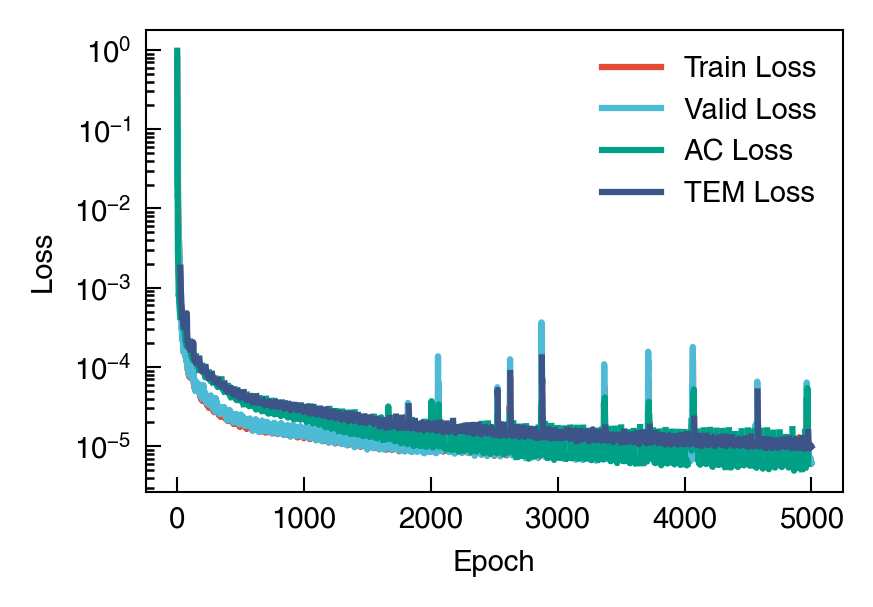

In [3]:
# read csv loss
import pandas as pd
save_dir = configs.save_dir
loss_df = pd.read_csv(os.path.join(save_dir, "logs.csv"))
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
ax.plot(loss_df["Epoch"], loss_df["TrainLoss"], label="Train Loss")
ax.plot(loss_df["Epoch"], loss_df["ValidLoss"], label="Valid Loss")
if configs.physical_residual:
    ax.plot(loss_df["Epoch"], loss_df["ACLoss"], label="AC Loss")
    ax.plot(loss_df["Epoch"], loss_df["TEMLoss"], label="TEM Loss")
ax.legend()
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")

Text(0, 0.5, 'MSE')

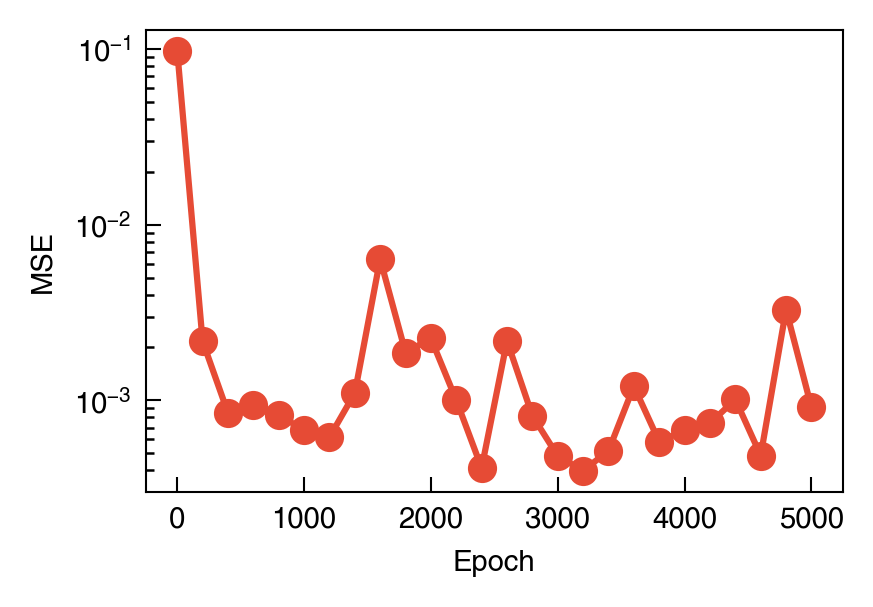

In [4]:
test_mse_df = pd.read_csv(os.path.join(save_dir, "test_logs.csv"))
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
ax.plot(test_mse_df["Epoch"], test_mse_df["TestMSE"], label="Test MSE", marker='o')
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")

In [5]:
# from model import model1d
from solidification.model2d import get_model2d

model_kwargs = {
   'modes_x': configs.modes_x,
   'modes_y': configs.modes_x,
   'width': configs.width,
   'depth': configs.depth,
   'activation': getattr(jax.nn, configs.activation),
   'key': jax.random.PRNGKey(0),
}

# Add VAE-specific parameters if needed
if configs.model_type == 'vae':
   model_kwargs.update({
      'latent_dim': configs.latent_dim,
      'output_size': configs.output_size,
   })

model_skeleton = get_model2d(
   configs.model_type,
   configs.in_channels,
   configs.out_channels,
   **model_kwargs
)
# model_skeleton = get_model1d(configs, jax.random.PRNGKey(0))
# weight = os.path.join(save_dir, f"epoch_{configs.epochs - 1}.eqx")
weight = os.path.join(save_dir, f"epoch_3200.eqx")
model = eqx.tree_deserialise_leaves(weight, model_skeleton)

In [30]:
# data = jnp.load("./dataset_split.npz")
data = jnp.load(os.path.join(configs.data_dir, "dataset_split.npz"))

# Xs, Ys = data["train_x"], data["train_y"]
Xs, Ys = data["valid_x"], data["valid_y"]
meshes = jnp.load(os.path.join(configs.data_dir, "dataset_2d_complete.npz"))["meshes"]
times = jnp.load(os.path.join(configs.data_dir, "dataset_2d_complete.npz"))["times"]
dt = times[1] - times[0]
# meshes = jnp.transpose(meshes, (2, 0, 1))
meshesx = meshes[0]
meshesy = meshes[1]
Xs.shape, Ys.shape

((250, 5, 129, 129), (250, 2, 129, 129))

In [31]:
Xs[:, 2, 0, 0].shape

(250,)

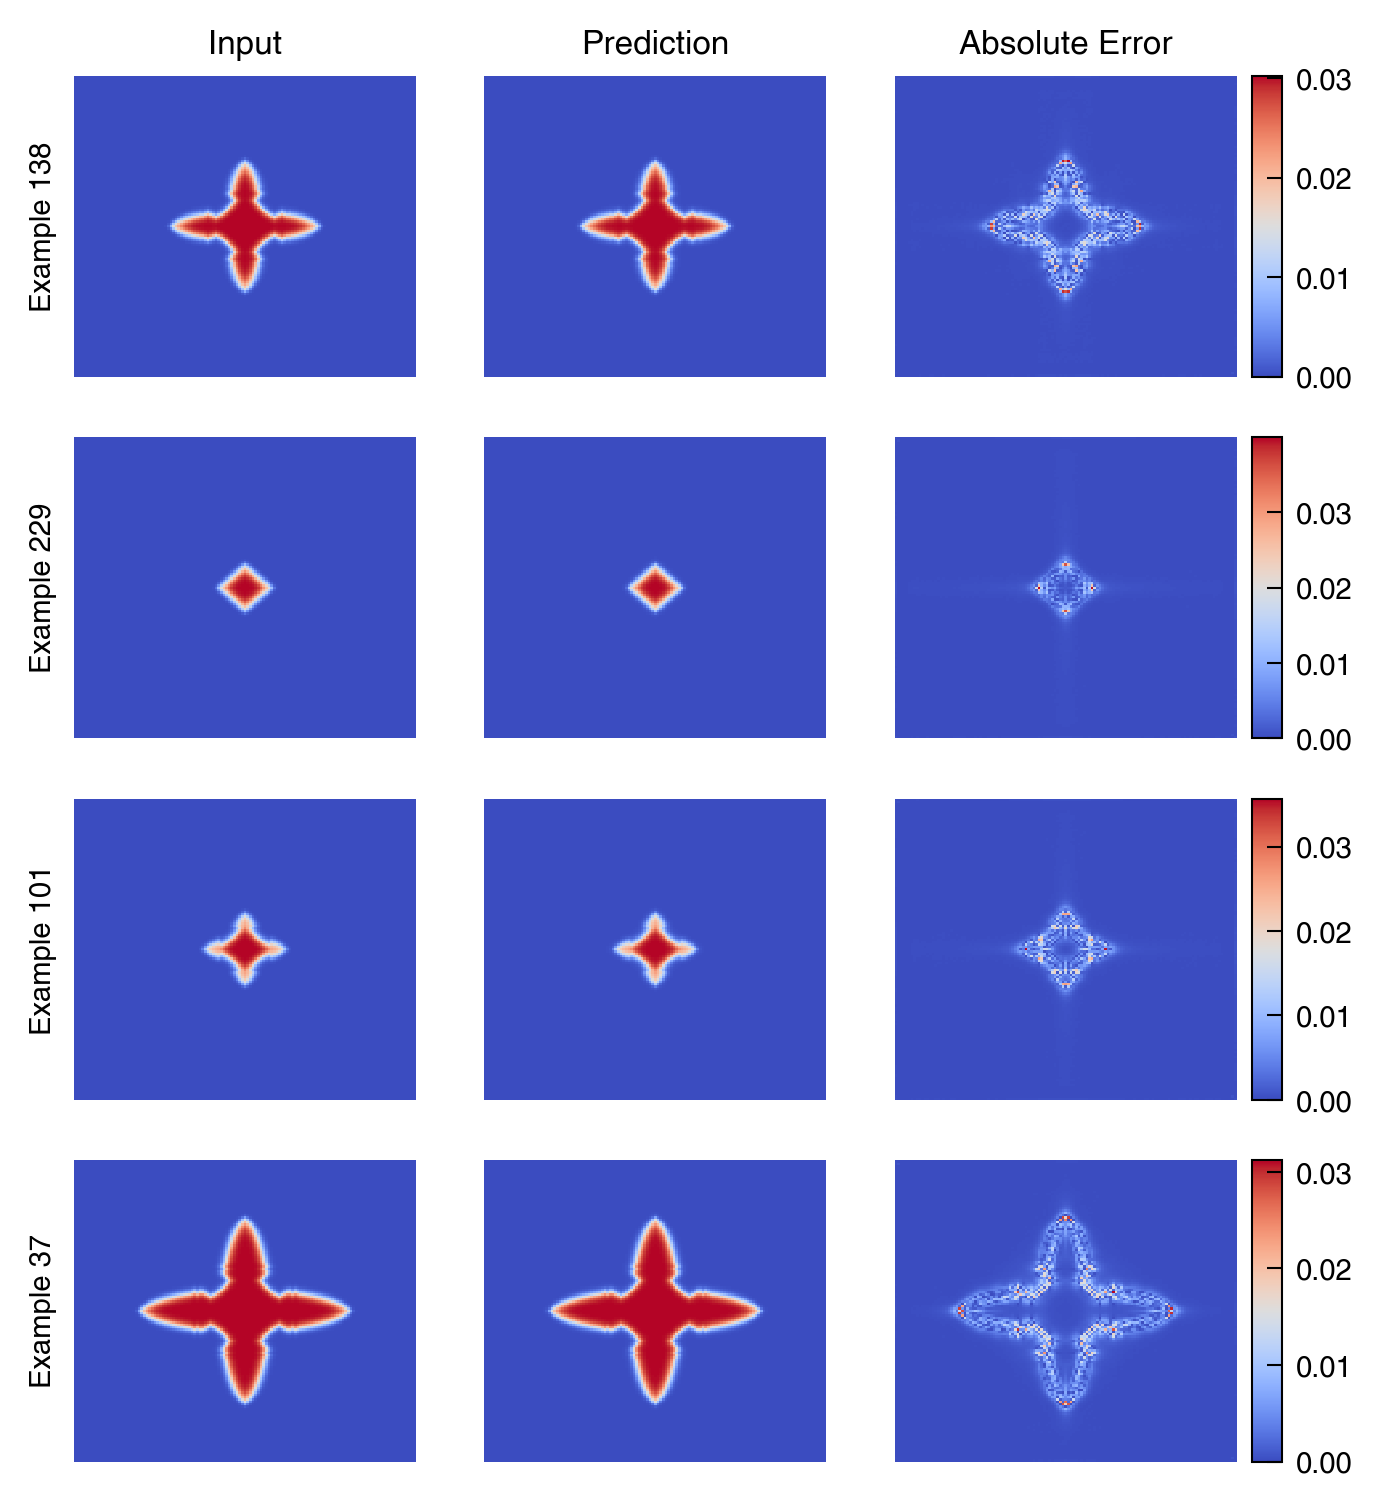

In [32]:
num_examples = 4
import numpy as np
random_indices = np.random.choice(Xs.shape[0], num_examples, replace=False)
fig, axes = plt.subplots(num_examples, 3, figsize=(5, 1.5 * num_examples))
xs_examples = Xs[random_indices]
ys_examples = Ys[random_indices]
# ks_examples = ks[random_indices]
y_pred_examples = jax.vmap(model.forward)(xs_examples)
component = 0

for i, idx in enumerate(random_indices):
    ax = axes[i, 0]
    # ax.contourf(meshesx, meshesy, xs_examples[i, 0, :, :], levels=100, cmap='coolwarm')
    ax.pcolormesh(meshesx, meshesy, ys_examples[i, component, :, :], shading='auto', cmap='coolwarm')
    ax.set_axis_off()
    # ax.set_ylabel(f"Example {idx}", rotation=0, labelpad=20, fontsize=8, va='center')
    ax.text(-0.05, 0.5, f"Example {idx}", rotation=90, va='center', ha="right", transform=ax.transAxes,)
    if i == 0:
        ax.text(0.5, 1.05, "Input", ha="center", va="bottom", transform=ax.transAxes, fontsize=8)

    ax = axes[i, 1]
    # ax.contourf(meshesx, meshesy, ys_examples[i, 0, :, :], levels=100, cmap='coolwarm')
    ax.pcolormesh(meshesx, meshesy, y_pred_examples[i, component, :, :], shading='auto', cmap='coolwarm')
    ax.set_axis_off()
    if i == 0:
        ax.text(0.5, 1.05, "Prediction", ha="center", va="bottom", transform=ax.transAxes, fontsize=8)

    ax = axes[i, 2]
    diff = jnp.abs(ys_examples[i, component, :, :] - y_pred_examples[i, component, :, :])
    # diff_ax = ax.contourf(meshesx, meshesy, diff, levels=100, cmap='coolwarm')
    diff_ax = ax.pcolormesh(meshesx, meshesy, diff, shading='auto', cmap='coolwarm')
    ax.set_axis_off()
    if i == 0:
        ax.text(0.5, 1.05, "Absolute Error", ha="center", va="bottom", transform=ax.transAxes, fontsize=8)

    ax_bar = fig.add_axes([ax.get_position().x1 + 0.01,
                           ax.get_position().y0,
                           0.02,
                           ax.get_position().height])
    fig.colorbar(diff_ax, cax=ax_bar)
# fig.tight_layout()

In [33]:
test_solutions = jnp.load(os.path.join(configs.test_data_dir, "solutions_grid.npy"))
test_ks = jnp.load(os.path.join(configs.test_data_dir, "K_values.npy")).reshape(-1, 1)
u0 = test_solutions[:, 0, :, :]
y_test = test_solutions[:, 1:, :, :]
auto_reg_fn = partial(
    model.auto_reg,
    meshes=meshes,
    steps=200
)
u_preds = jax.vmap(auto_reg_fn)(u0, test_ks)

In [34]:
test_solutions.shape, u_preds.shape, y_test.shape

((4, 201, 2, 129, 129), (4, 200, 2, 129, 129), (4, 200, 2, 129, 129))

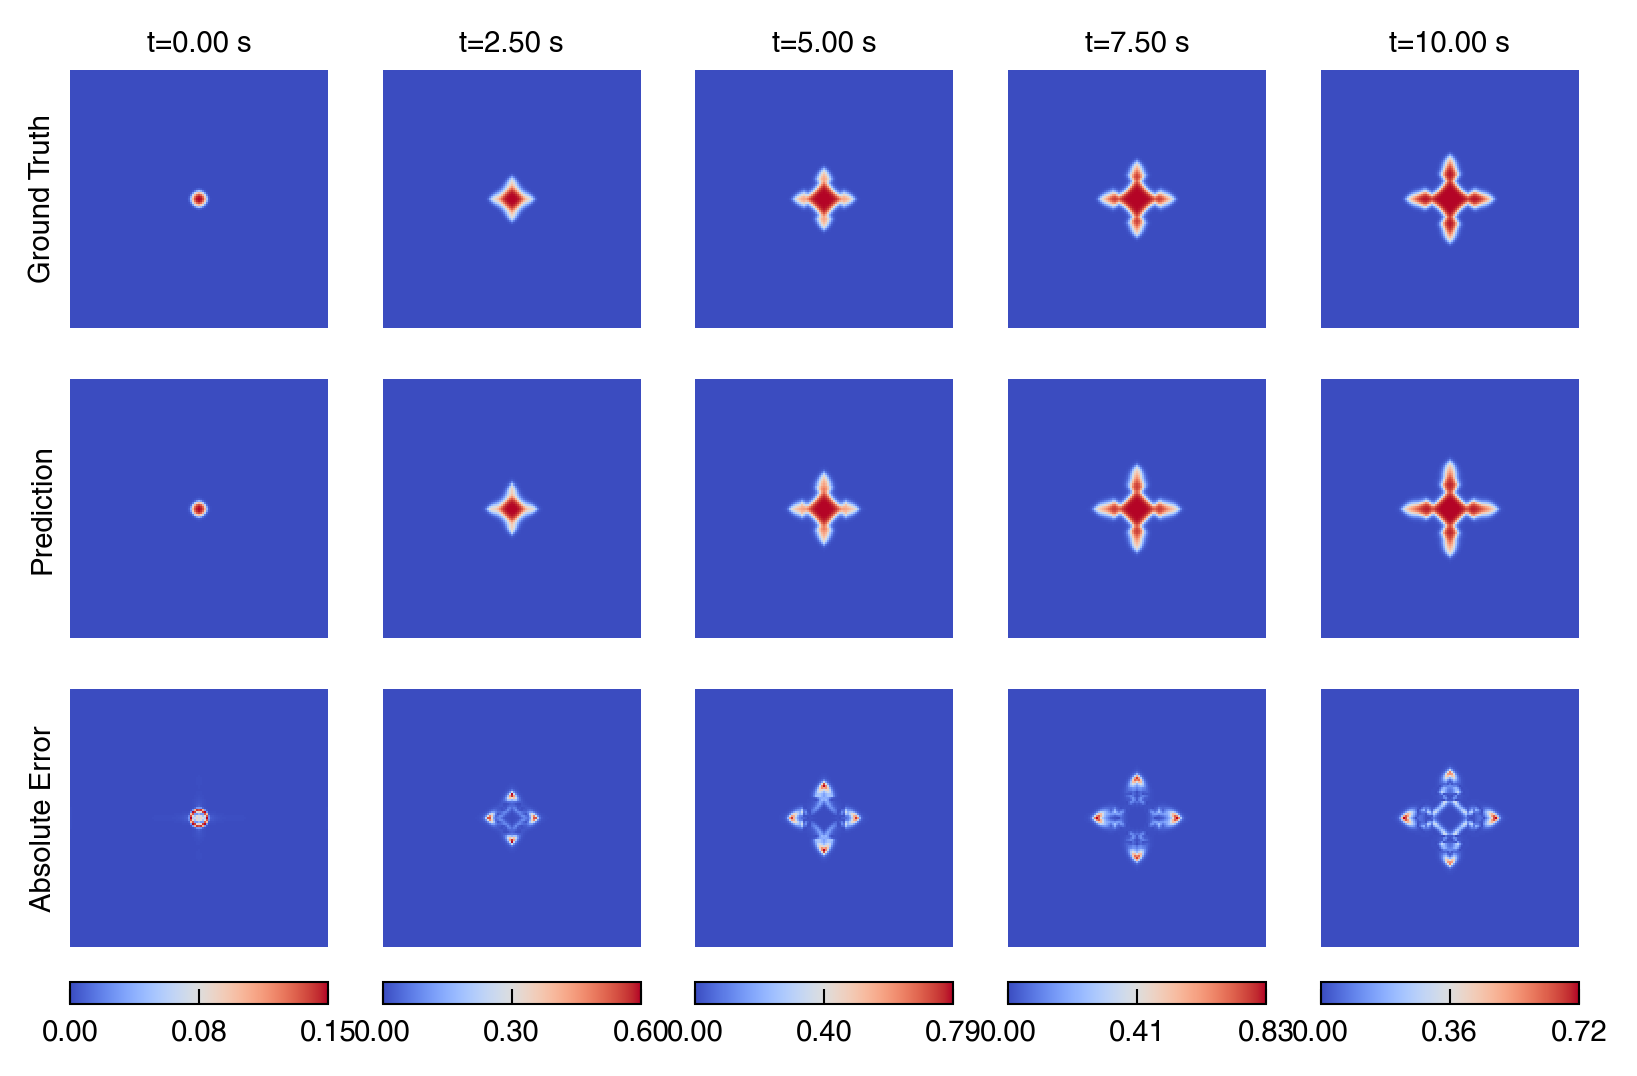

In [35]:
idxs = [0, 50, 100, 150, 200]
meshesx = meshes[0]
meshesy = meshes[1]
example_th = -1
component = 0
fig, axes = plt.subplots(3, len(idxs), figsize=(1.3 * len(idxs), 3.8),)
for i, idx in enumerate(idxs):
    ax = axes[0, i]
    # ax.contourf(meshesx, meshesy, y_test[example_th, idx, 0, :, :], levels=20, cmap='coolwarm')
    ax.pcolormesh(meshesx, meshesy, y_test[example_th, idx, component, :, :], shading='auto', cmap='coolwarm')
    if i == 0:
        ax.text(-0.05, 0.5, "Ground Truth", ha="right", va="center", transform=ax.transAxes, rotation=90)
    # ax.set_title(f"Ground Truth t={int((idx+1)*dt*configs.Tc)} s")
    ax.set_axis_off()
    ax.text(0.5, 1.05, f"t={idx*dt*configs.Tc:.2f} s", ha="center", va="bottom", transform=ax.transAxes)
    ax.set_aspect('equal')

    ax = axes[1, i]
    # ax.contourf(meshesx, meshesy, u_preds[example_th, idx, 0, :, :], levels=20, cmap='coolwarm')
    ax.pcolormesh(meshesx, meshesy, u_preds[example_th, idx, component, :, :], shading='auto', cmap='coolwarm')
    if i == 0:
        ax.text(-0.05, 0.5, "Prediction", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = axes[2, i]
    diff = jnp.abs(y_test[example_th, idx, component, :, :] - u_preds[example_th, idx, component, :, :])
    # diff_ax = ax.contourf(meshesx, meshesy, diff, levels=20, cmap='coolwarm')
    diff_ax = ax.pcolormesh(meshesx, meshesy, diff, shading='auto', cmap='coolwarm')
    if i == 0:
        ax.text(-0.05, 0.5, "Absolute Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax_bar = fig.add_axes([ax.get_position().x0,
                           ax.get_position().y0 - 0.05,
                           ax.get_position().width,
                           0.02])
    
    # L2 = jnp.linalg.norm(y_test[example_th, idx, component, :, :] - u_preds[example_th, idx, component, :, :]) / jnp.linalg.norm(y_test[example_th, idx, component, :, :])
    # # format as latex string wish scientific notation (\times 10^)
    # L2_magnitude = jnp.floor(jnp.log10(L2))
    # L2_coefficient = L2 / (10 ** L2_magnitude)
    # L2_text = r"$L_2=" + f"{L2_coefficient:.2f}" + r"\times 10^{" + f"{int(L2_magnitude)}" + "}$"
    # ax.text(0.01, 0.99, L2_text, ha="left", va="top", transform=ax.transAxes, fontsize=5, color='white')
    
    # fewer ticks on colorbar with 2 precision
    fig.colorbar(diff_ax, cax=ax_bar, orientation='horizontal',
                 format='%.2f', ticks=jnp.linspace(0, jnp.max(diff), num=3))

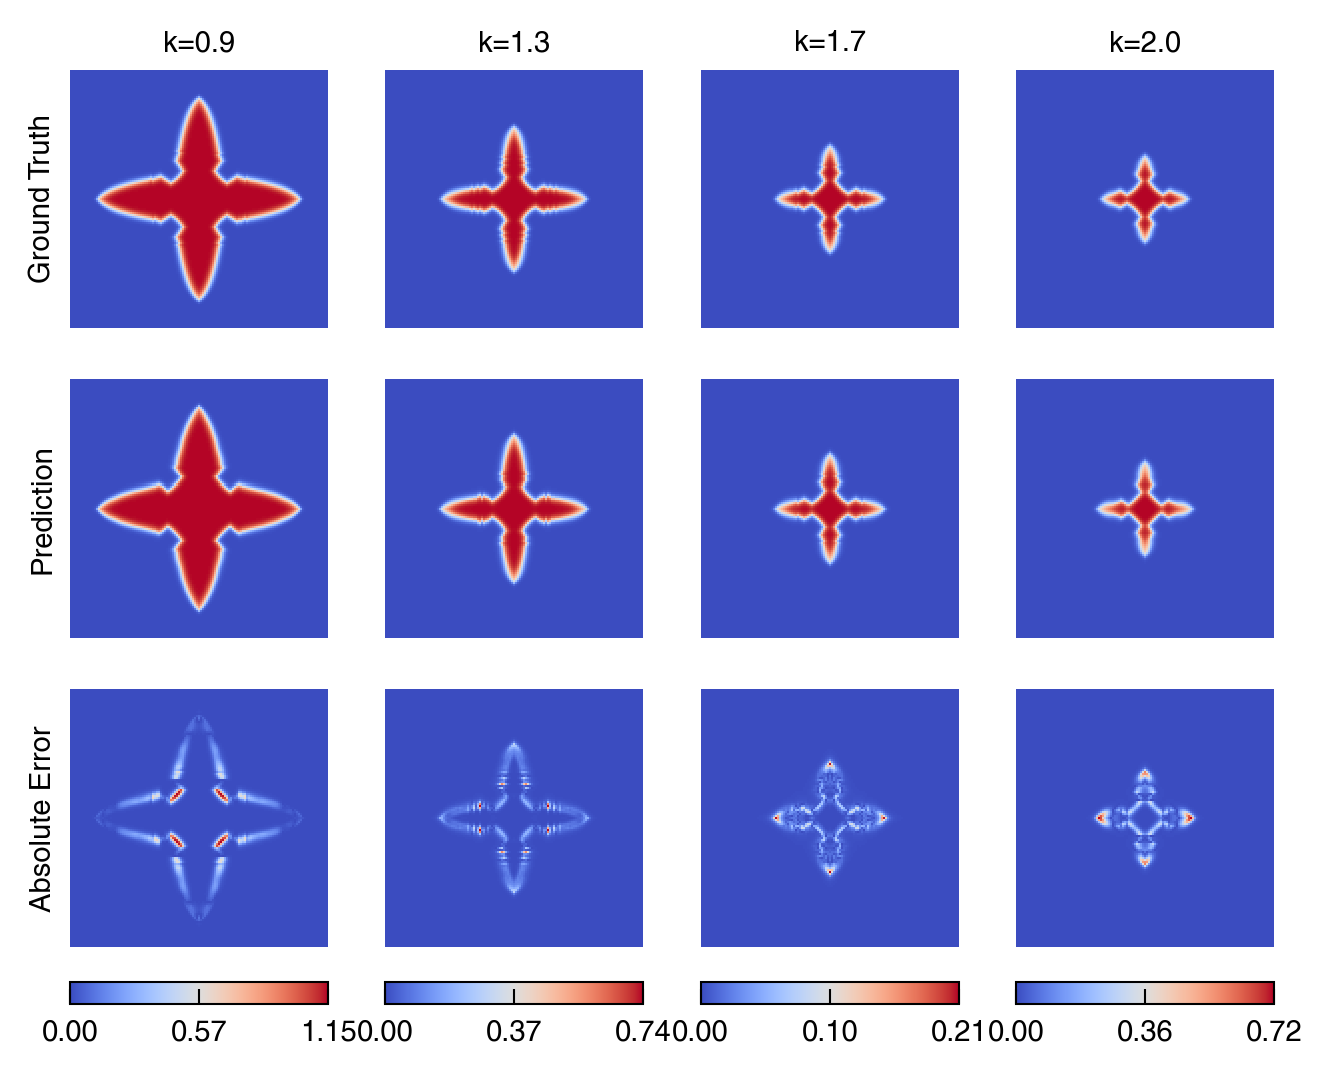

In [36]:
# Final time step, with different ks

meshesx = meshes[0]
meshesy = meshes[1]
example_ths = [0, 1, 2, 3]
idx = -1
component = 0
fig, axes = plt.subplots(3, len(example_ths), figsize=(1.3 * len(example_ths), 3.8),)
for i, example_th in enumerate(example_ths):
    ax = axes[0, i]
    # ax.contourf(meshesx, meshesy, y_test[example_th, idx, 0, :, :], levels=20, cmap='coolwarm')
    ax.pcolormesh(meshesx, meshesy, y_test[example_th, idx, component, :, :], shading='auto', cmap='coolwarm')
    if i == 0:
        ax.text(-0.05, 0.5, "Ground Truth", ha="right", va="center", transform=ax.transAxes, rotation=90)
    # ax.set_title(f"Ground Truth t={int((idx+1)*dt*configs.Tc)} s")
    ax.set_axis_off()
    ax.text(0.5, 1.05, f"k={test_ks[example_th, -1]:.1f}", ha="center", va="bottom", transform=ax.transAxes)
    ax.set_aspect('equal')

    ax = axes[1, i]
    # ax.contourf(meshesx, meshesy, u_preds[example_th, idx, 0, :, :], levels=20, cmap='coolwarm')
    ax.pcolormesh(meshesx, meshesy, u_preds[example_th, idx, component, :, :], shading='auto', cmap='coolwarm')
    if i == 0:
        ax.text(-0.05, 0.5, "Prediction", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = axes[2, i]
    diff = jnp.abs(y_test[example_th, idx, component, :, :] - u_preds[example_th, idx, component, :, :])
    # diff_ax = ax.contourf(meshesx, meshesy, diff, levels=20, cmap='coolwarm')
    diff_ax = ax.pcolormesh(meshesx, meshesy, diff, shading='auto', cmap='coolwarm')
    if i == 0:
        ax.text(-0.05, 0.5, "Absolute Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax_bar = fig.add_axes([ax.get_position().x0,
                           ax.get_position().y0 - 0.05,
                           ax.get_position().width,
                           0.02])
    
    # L2 = jnp.linalg.norm(y_test[example_th, idx, component, :, :] - u_preds[example_th, idx, component, :, :]) / jnp.linalg.norm(y_test[example_th, idx, component, :, :])
    # # format as latex string wish scientific notation (\times 10^)
    # L2_magnitude = jnp.floor(jnp.log10(L2))
    # L2_coefficient = L2 / (10 ** L2_magnitude)
    # L2_text = r"$L_2=" + f"{L2_coefficient:.2f}" + r"\times 10^{" + f"{int(L2_magnitude)}" + "}$"
    # ax.text(0.01, 0.99, L2_text, ha="left", va="top", transform=ax.transAxes, fontsize=5, color='white')
    
    # fewer ticks on colorbar with 2 precision
    fig.colorbar(diff_ax, cax=ax_bar, orientation='horizontal',
                 format='%.2f', ticks=jnp.linspace(0, jnp.max(diff), num=3))

In [37]:
mse = jnp.mean((y_test - u_preds) ** 2)
mse

Array(0.00051654, dtype=float32)

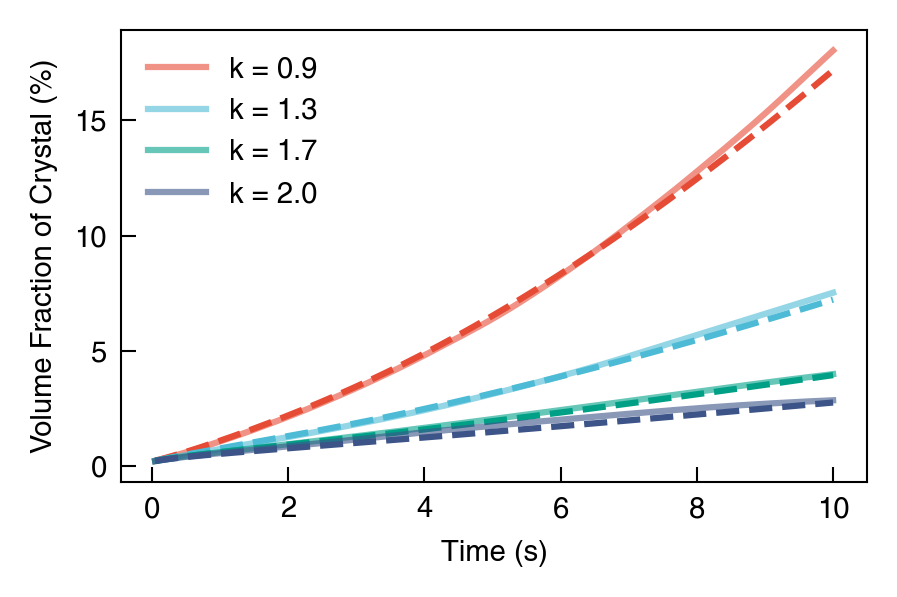

In [39]:
evo_frac = jnp.mean((y_test+1)/2, axis=(-1, -2))[..., 0]
evo_frac_pred = jnp.mean((u_preds+1)/2, axis=(-1, -2))[..., 0]

fig, ax = plt.subplots(1, 1, figsize=(3, 2))
for i in range( evo_frac.shape[0]):
    ax.plot(times[1:], evo_frac[i, :], color=f"C{i}", ls="--")
    ax.plot(times[1:], evo_frac_pred[i, :], color=f"C{i}", alpha=0.6, label=f"k = {test_ks[i,0]:.1f}")

# from matplotlib.lines import Line2D
# custom_lines = [Line2D([0], [0], color='black', ls='--'),
#                 Line2D([0], [0], color='black', ls='-')]
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x * 100:.0f}'))
ax.set_xlabel("Time (s)")
ax.set_ylabel("Volume Fraction of Crystal (%)")
fig.tight_layout()

In [47]:
# acc logs
test_solutions = jnp.load(os.path.join(configs.test_data_dir, "solutions_grid.npy"))
test_ks = jnp.load(os.path.join(configs.test_data_dir, "K_values.npy")).reshape(-1, 1)
# drop the first test example (cause it's speed is too fast, exceeding the domain.)
u0 = test_solutions[:, 0, :, :]
y_test = test_solutions[:, 1:, :, :]
epochs = jnp.arange(0, 5000, 200)
mse_list = []
for epoch in epochs:
    weight = os.path.join(save_dir, f"epoch_{epoch}.eqx")
    model = eqx.tree_deserialise_leaves(weight, model_skeleton)

    auto_reg_fn = partial(
        model.auto_reg,
        meshes=meshes,
        steps=200
    )
    u_preds = jax.vmap(auto_reg_fn)(u0, test_ks)

    mse = jnp.mean((y_test - u_preds) ** 2,)
    mse_list.append(mse)

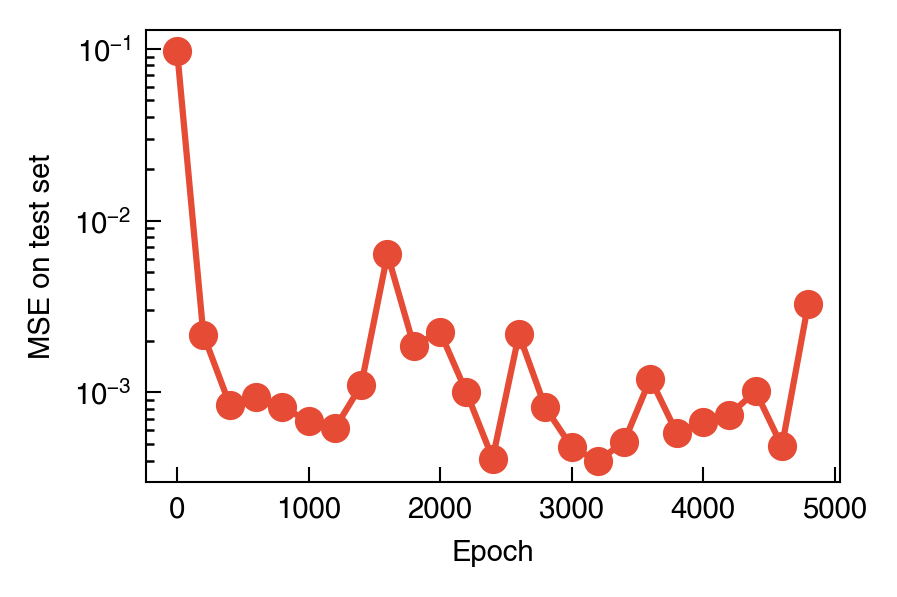

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
ax.plot(epochs, mse_list, marker='o')
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE on test set")
plt.tight_layout()

In [17]:
# save test mse
path = os.path.join(save_dir, "test_mse.npy")
jnp.save(path, jnp.array(mse_list))

## Fine-tune on the extrapolation set

In [18]:
class FDM2d:
    """
    Finite Difference Method for 2D Corrosion Modeling.
    """
    @staticmethod
    @eqx.filter_jit
    def nabla(
        u: jnp.ndarray,
        dx: float,
        dy: float
    ) -> jnp.ndarray:
        r"""
        Compute $\nabla u$ using central difference.
        $\nabla u = (du/dx, du/dy)$
        """
        dudx = jnp.zeros_like(u)
        dudy = jnp.zeros_like(u)

        # 首先，x和y坐标对应数组的列和行
        # 其次，y的正方向本来是向上的，但是为了和数组的索引向下对应，我们的meshy实际上也是从上到下增大的
        dudx = dudx.at[:, 1:-1].set((u[:, 2:] - u[:, :-2]) / (2 * dx))
        dudy = dudy.at[1:-1, :].set((u[2:, :] - u[:-2, :]) / (2 * dy))

        dudx = dudx.at[:, 0].set((-3*u[:, 0] + 4*u[:, 1] - u[:, 2]) / (2*dx))
        dudx = dudx.at[:, -1].set((3*u[:, -1] - 4*u[:, -2] + u[:, -3]) / (2*dx))

        dudy = dudy.at[0, :].set((-3*u[0, :] + 4*u[1, :] - u[2, :]) / (2*dy))
        dudy = dudy.at[-1, :].set((3*u[-1, :] - 4*u[-2, :] + u[-3, :]) / (2*dy))


        return jnp.stack([dudx, dudy], axis=0)
    
    @staticmethod
    @eqx.filter_jit
    def divergence(
        vec_field: jnp.ndarray,
        dx: float,
        dy: float
    ) -> jnp.ndarray:
        r"""
        Compute $\nabla \cdot \mathbf{F}$ using central difference.
        $\nabla \cdot \mathbf{F} = dF_x/dx + dF_y/dy$
        """
        Fx = vec_field[0, :, :]
        Fy = vec_field[1, :, :]

        dFxdx = jnp.zeros_like(Fx)
        dFydy = jnp.zeros_like(Fy)

        dFxdx = dFxdx.at[:, 1:-1].set((Fx[:, 2:] - Fx[:, :-2]) / (2 * dx))
        dFxdx = dFxdx.at[:, 0].set((-3*Fx[:, 0] + 4*Fx[:, 1] - Fx[:, 2]) / (2*dx))
        dFxdx = dFxdx.at[:, -1].set((3*Fx[:, -1] - 4*Fx[:, -2] + Fx[:, -3]) / (2*dx))

        dFydy = dFydy.at[1:-1, :].set((Fy[2:, :] - Fy[:-2, :]) / (2 * dy))
        dFydy = dFydy.at[0, :].set((-3*Fy[0, :] + 4*Fy[1, :] - Fy[2, :]) / (2*dy))
        dFydy = dFydy.at[-1, :].set((3*Fy[-1, :] - 4*Fy[-2, :] + Fy[-3, :]) / (2*dy))

        return dFxdx + dFydy
    
    @staticmethod
    @eqx.filter_jit
    def laplacian(
        u: jnp.ndarray,
        dx: float,
        dy: float
    ) -> jnp.ndarray:
        """
        Compute $\nabla^2 u$ using central difference.
        $\nabla^2 u = d^2u/dx^2 + d^2u/dy^2$
        """
        d2udx2 = jnp.zeros_like(u)
        d2udy2 = jnp.zeros_like(u)

        d2udx2 = d2udx2.at[:, 1:-1].set((u[:, 2:] - 2 * u[:, 1:-1] + u[:, :-2]) / (dx ** 2))
        d2udx2 = d2udx2.at[:, 0].set((2.0*u[:, 0] - 5.0*u[:, 1] + 4.0*u[:, 2] - u[:, 3]) / (dx ** 2))
        d2udx2 = d2udx2.at[:, -1].set((2.0*u[:, -1] - 5.0*u[:, -2] + 4.0*u[:, -3] - u[:, -4]) / (dx ** 2))

        d2udy2 = d2udy2.at[1:-1, :].set((u[2:, :] - 2 * u[1:-1, :] + u[:-2, :]) / (dy ** 2))
        d2udy2 = d2udy2.at[0, :].set((2.0*u[0, :] - 5.0*u[1, :] + 4.0*u[2, :] - u[3, :]) / (dy ** 2))
        d2udy2 = d2udy2.at[-1, :].set((2.0*u[-1, :] - 5.0*u[-2, :] + 4.0*u[-3, :] - u[-4, :]) / (dy ** 2))

        return d2udx2 + d2udy2

In [19]:

def kappa(gradx, grady, sigma, eps=1e-12):
    norm_sq = gradx**2 + grady**2 + eps
    cos2theta = (gradx**2 - grady**2) / norm_sq
    sin2theta = 2 * gradx * grady / norm_sq
    cos4theta = cos2theta**2 - sin2theta**2
    return 1 + sigma * cos4theta


def H(gradx, grady, sigma, eps=1e-6):
    norm_sq = gradx**2 + grady**2
    
    # 只有当梯度模长足够大时才计算各向异性项
    # 否则在平坦区域，除以极小的 norm6 会导致梯度爆炸或数值噪声
    valid_mask = norm_sq > 1e-3
    
    norm6 = norm_sq**3 + eps
    coef = 16.0 * sigma / norm6
    Hx = coef * gradx * (gradx**2 * grady**2 - grady**4)
    Hy = coef * grady * (grady**2 * gradx**2 - gradx**4)
    
    # 使用 where 过滤掉噪声
    Hx = jnp.where(valid_mask, Hx, 0.0)
    Hy = jnp.where(valid_mask, Hy, 0.0)
    
    return jnp.stack([Hx, Hy], axis=0)

In [20]:

def pde_loss_rollout(model, u0s, ks, meshes, steps, ys, dx, dy, dt, pde_name, **kwargs):

    def auto_reg_fn(u0, k):
        k_val = k[0] if k.ndim > 0 else k
        k_channel = jnp.full((1, meshes.shape[1], meshes.shape[2]), k_val)

        def scan_fn(carry, _):
            u_prev = jax.lax.stop_gradient(carry)
            inputs = jnp.concatenate([u_prev, k_channel, meshes], axis=0) 
            u_next = model.forward(inputs)
            return u_next, u_next
        
        _, u_preds = jax.lax.scan(scan_fn, u0, None, length=steps)
        return u_preds 

    # 1. 运行自回归生成预测
    # 确保 ks 的 batch 维度与 u0s 一致
    if ks.shape[0] != u0s.shape[0]:
         ks = jnp.repeat(ks, u0s.shape[0], axis=0)
         
    pred = jax.vmap(auto_reg_fn, in_axes=(0,0))(u0s, ks) # (batch, steps, channels, nx, ny)
    
    # 计算 MSE (确保 ys 长度匹配，防止 ys 比 steps 长导致报错)
    ys_sliced = ys[:, :steps, :, :, :]
    mse_error = jnp.mean((pred - ys_sliced)**2)

    # 2. 准备计算残差的数据
    # curr: t 时刻的状态 (作为输入)
    curr = jnp.concatenate([u0s[:, None, :, :, :], pred[:, :-1, :, :, :]], axis=1)
    curr = jax.lax.stop_gradient(curr)
    
    # 3. Flatten batch 和 steps 维度
    batch_size, n_steps, channels, nx, ny = curr.shape
    
    curr_flat = curr.reshape(batch_size * n_steps, channels, nx, ny)
    pred_flat = pred.reshape(batch_size * n_steps, channels, nx, ny)
    
    # ks 也需要扩展并 flatten
    # ks: (batch, 1) -> tile -> (batch, steps) -> flatten -> (batch*steps, )
    ks_expanded = jnp.tile(ks, (1, n_steps)) 
    ks_flat = ks_expanded.reshape(-1) 

    # 4. 定义单步残差函数
    def one_step_ac_residual(curr, pred, k, dx, dy, dt):
        phi0 = curr[0, :, :]
        T0 = curr[1, :, :]
        phi = pred[0, :, :]
        T = pred[1, :, :]
        
        dphi_dt = (phi - phi0) / dt / configs.Tc
        nabla_phi = FDM2d.nabla(phi, dx, dy) / configs.Lc
        grad_phi_x = nabla_phi[0, :, :]
        grad_phi_y = nabla_phi[1, :, :]
        grad_phi_2 = grad_phi_x**2 + grad_phi_y**2
        kappa_val = kappa(grad_phi_x, grad_phi_y, configs.sigma)
        H_val = H(grad_phi_x, grad_phi_y, configs.sigma)
        vec_field = kappa_val**2 * nabla_phi + kappa_val * grad_phi_2 * H_val
        div_term = FDM2d.divergence(vec_field, dx, dy) / configs.Lc
        F_prime = phi**3 - phi
        h_prime = phi**4 - 2 * phi**2 + 1
        residual = (
            configs.rho_val * dphi_dt
            - div_term
            + F_prime / (configs.epsilon ** 2)
            + configs.lam / configs.epsilon * h_prime * T
        )
        return residual / configs.AC_PRE_SCALE / 2
    
    def one_step_tem_residual(curr, pred, k, dx, dy, dt):
        phi0 = curr[0, :, :]
        T0 = curr[1, :, :]
        phi = pred[0, :, :]
        T = pred[1, :, :]
        dT_dt = (T - T0) / dt / configs.Tc
        lap_T = FDM2d.laplacian(T, dx, dy) / configs.Lc**2
        h_prime = phi**4 - 2 * phi**2 + 1
        dphi_dt = (phi - phi0) / dt / configs.Tc
        residual = (
            dT_dt - configs.D_val * lap_T - k * h_prime * dphi_dt
        )
        return residual / configs.TEM_PRE_SCALE

    residual_fn = one_step_ac_residual if pde_name == "AC" else one_step_tem_residual

    # 5. 使用单层 vmap 计算所有步的残差
    residual_flat = jax.vmap(
        residual_fn, 
        in_axes=(0, 0, 0, None, None, None)
    )(curr_flat, pred_flat, ks_flat, dx, dy, dt)

    pde_loss = jnp.mean(residual_flat**2)
    return pde_loss, mse_error

In [21]:
# dx = meshesx[0,1] - meshesx[0,0]
# dy = meshesy[1,0] - meshesy[0,0]
# dt = times[1] - times[0]


# loss_rollout_fn = partial(
#     pde_loss_rollout,
#     meshes=meshes,
#     steps=200,
#     dx=dx,
#     dy=dy,
#     dt=dt,
# )

# import optax
# optimizer = optax.adam(5e-6)
# opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

# @eqx.filter_jit
# def make_step(loss_fn, model, opt_state, u0s, ks, ys,):
#     (loss, mse_error), grads = eqx.filter_value_and_grad(loss_fn, has_aux=True)(
#         model, u0s=u0s, ks=ks, ys=ys)
#     grads = jax.tree.map(lambda x: jnp.nan_to_num(x), grads) # 防止 NaN 传播
#     updates, opt_state = optimizer.update(grads, opt_state, model)
#     model = eqx.apply_updates(model, updates)
#     return model, opt_state, (loss, mse_error)

# roll_out_loss_fn_ac = partial(
#     loss_rollout_fn,
#     pde_name="AC",
# )
# roll_out_loss_fn_tem = partial(
#     loss_rollout_fn,
#     pde_name="TEM",
# )



# fine_tune_losses_ac = []
# fine_tune_losses_tem = []
# fine_tune_mse = []
# fine_tune_epochs = 1000
# test_solutions = jnp.load("/root/autodl-tmp/data/solidification/test_K1.8/solutions_grid.npy")
# test_ks = jnp.array([1.8]).reshape(-1, 1)
# u0 = test_solutions[:, 0, :, :]
# y_test = test_solutions[:, 1:, :, :]


# weight = os.path.join(save_dir, f"epoch_2800.eqx")
# model = eqx.tree_deserialise_leaves(weight, model_skeleton)
# for epoch in range(fine_tune_epochs):
#     pde_name = "TEM" if epoch % 2 < 1 else "AC"
#     loss_fn = roll_out_loss_fn_ac if pde_name == "AC" else roll_out_loss_fn_tem
#     model, opt_state, (loss, mse_error) = make_step(
#         loss_fn,
#         model,
#         opt_state,
#         u0s=u0,
#         ks=test_ks,
#         ys=y_test,
#     )
#     if pde_name == "AC":
#         fine_tune_losses_ac.append(loss)
#     else:
#         fine_tune_losses_tem.append(loss)
#     fine_tune_mse.append(mse_error)
#     print(f"Epoch {epoch}, PDE: {pde_name}, Loss: {loss:.6e}, MSE: {mse_error:.6e}")
    

In [22]:
# # plot the loss and mse curves during fine-tuning
# fig, ax = plt.subplots(2, 1, figsize=(3, 4))
# ax[0].plot(fine_tune_losses_ac, label="AC Loss")
# ax[0].plot(fine_tune_losses_tem, label="TEM Loss")
# ax[0].set_yscale("log")
# ax[0].set_xlabel("Fine-tune Epoch")
# ax[0].set_ylabel("PDE Loss")
# ax[0].legend()

# ax[1].plot(fine_tune_mse, label="MSE", color='C2')
# ax[1].set_yscale("log")
# ax[1].set_xlabel("Fine-tune Epoch")
# ax[1].set_ylabel("MSE on test set")
# plt.tight_layout()

In [23]:
# weight = os.path.join(save_dir, f"epoch_2800.eqx")
# model = eqx.tree_deserialise_leaves(weight, model_skeleton)
test_solutions = jnp.load("/root/autodl-tmp/data/solidification/test_K1.8/solutions_grid.npy")
test_ks = jnp.array([1.8]).reshape(-1, 1)
u0 = test_solutions[:, 0, :, :]
y_test = test_solutions[:, 1:, :, :]
auto_reg_fn = partial(
    model.auto_reg,
    meshes=meshes,
    steps=200
)
u_preds = jax.vmap(auto_reg_fn)(u0, test_ks)

In [24]:
mse = jnp.mean((y_test - u_preds) ** 2,)
print(f"Final MSE after fine-tuning: {mse:.6f}")

Final MSE after fine-tuning: 0.000233


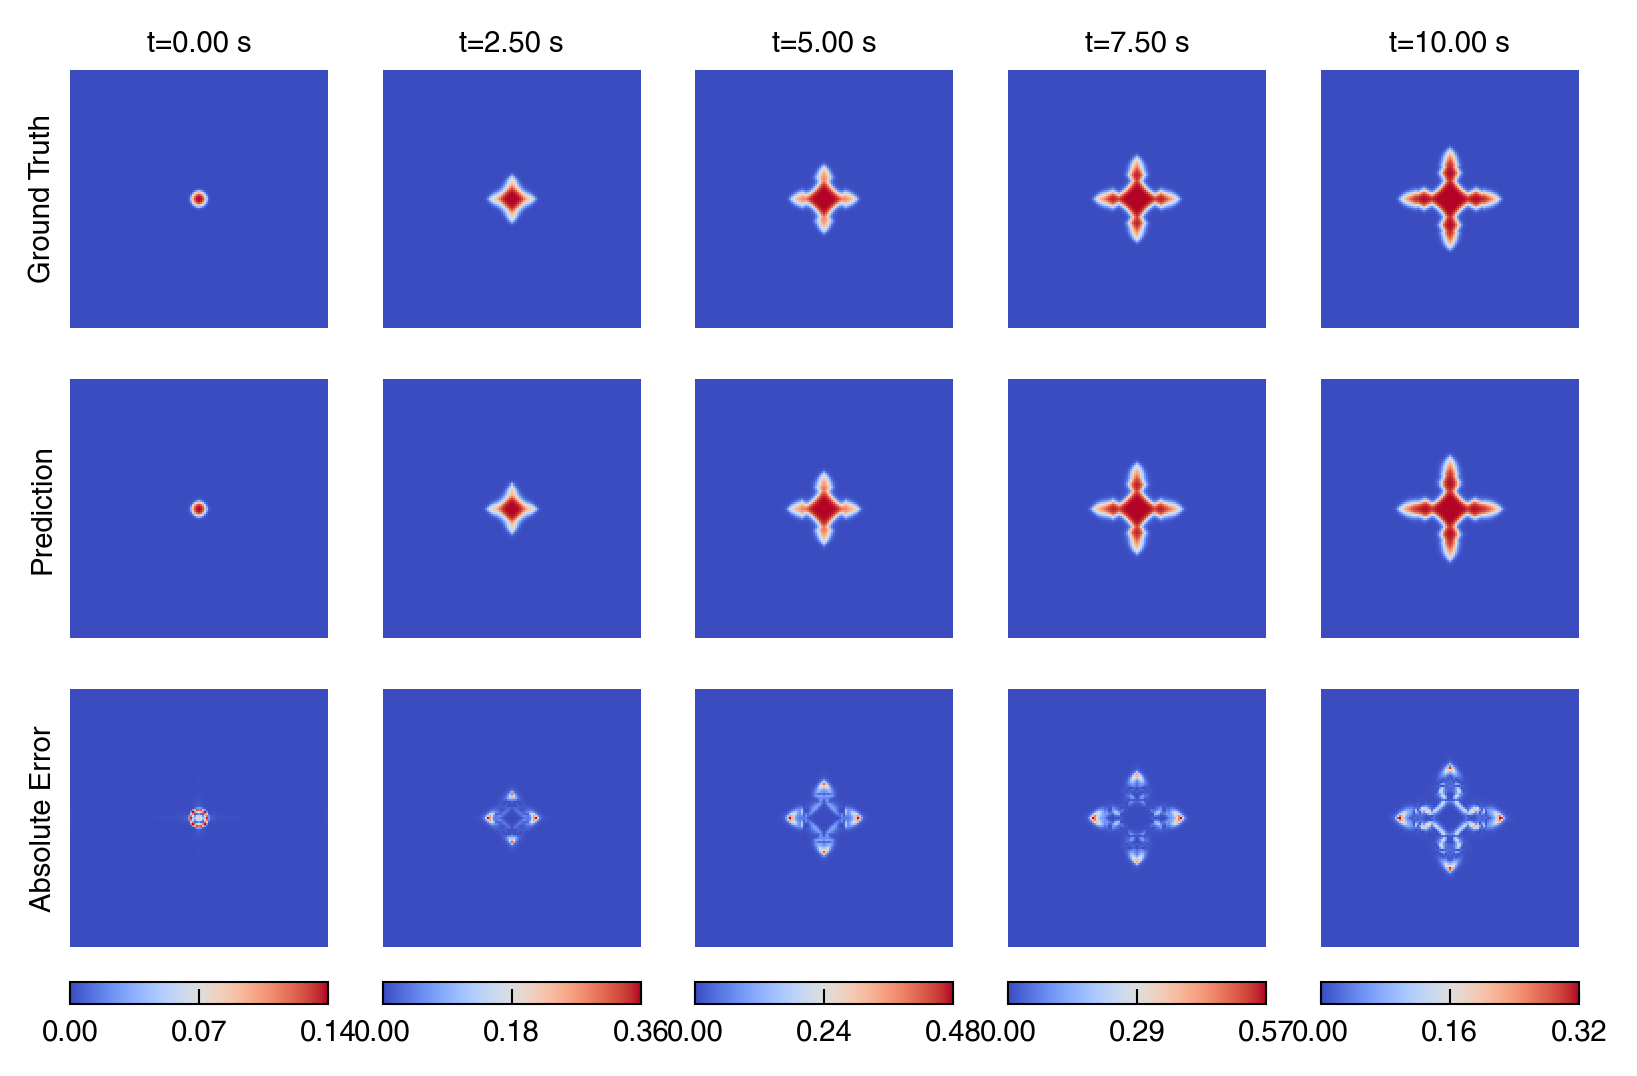

In [25]:
idxs = [0, 50, 100, 150, 200]
meshesx = meshes[0]
meshesy = meshes[1]
example_th = 0
component = 0
fig, axes = plt.subplots(3, len(idxs), figsize=(1.3 * len(idxs), 3.8),)
for i, idx in enumerate(idxs):
    ax = axes[0, i]
    # ax.contourf(meshesx, meshesy, y_test[example_th, idx, 0, :, :], levels=20, cmap='coolwarm')
    ax.pcolormesh(meshesx, meshesy, y_test[example_th, idx, component, :, :], shading='auto', cmap='coolwarm')
    if i == 0:
        ax.text(-0.05, 0.5, "Ground Truth", ha="right", va="center", transform=ax.transAxes, rotation=90)
    # ax.set_title(f"Ground Truth t={int((idx+1)*dt*configs.Tc)} s")
    ax.set_axis_off()
    ax.text(0.5, 1.05, f"t={idx*dt*configs.Tc:.2f} s", ha="center", va="bottom", transform=ax.transAxes)
    ax.set_aspect('equal')

    ax = axes[1, i]
    # ax.contourf(meshesx, meshesy, u_preds[example_th, idx, 0, :, :], levels=20, cmap='coolwarm')
    ax.pcolormesh(meshesx, meshesy, u_preds[example_th, idx, component, :, :], shading='auto', cmap='coolwarm')
    if i == 0:
        ax.text(-0.05, 0.5, "Prediction", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = axes[2, i]
    diff = jnp.abs(y_test[example_th, idx, component, :, :] - u_preds[example_th, idx, component, :, :])
    # diff_ax = ax.contourf(meshesx, meshesy, diff, levels=20, cmap='coolwarm')
    diff_ax = ax.pcolormesh(meshesx, meshesy, diff, shading='auto', cmap='coolwarm')
    if i == 0:
        ax.text(-0.05, 0.5, "Absolute Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax_bar = fig.add_axes([ax.get_position().x0,
                           ax.get_position().y0 - 0.05,
                           ax.get_position().width,
                           0.02])
    
    # L2 = jnp.linalg.norm(y_test[example_th, idx, component, :, :] - u_preds[example_th, idx, component, :, :]) / jnp.linalg.norm(y_test[example_th, idx, component, :, :])
    # # format as latex string wish scientific notation (\times 10^)
    # L2_magnitude = jnp.floor(jnp.log10(L2))
    # L2_coefficient = L2 / (10 ** L2_magnitude)
    # L2_text = r"$L_2=" + f"{L2_coefficient:.2f}" + r"\times 10^{" + f"{int(L2_magnitude)}" + "}$"
    # ax.text(0.01, 0.99, L2_text, ha="left", va="top", transform=ax.transAxes, fontsize=5, color='white')
    
    # fewer ticks on colorbar with 2 precision
    fig.colorbar(diff_ax, cax=ax_bar, orientation='horizontal',
                 format='%.2f', ticks=jnp.linspace(0, jnp.max(diff), num=3))